# 1. Imports

In [116]:
import os
import pandas as pd
import numpy as np
from time import time
from glob import glob
from collections import defaultdict as default_dict

# Matplotlib
from matplotlib import pyplot as plt

# Tensorflow
#os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import tensorflow as tf
tf.config.set_visible_devices([], 'GPU')
from tensorflow.keras import Model, Input
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50, VGG16
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess_input
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess_input

# Sklearn
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score, davies_bouldin_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Seaborn
import seaborn as sns


# 2. Préparation des données

In [117]:
path = "/content/drive/MyDrive/data/Flipkart"
#path = "./data/Flipkart"

In [118]:
data = pd.read_csv(path+'/cleaned_data.csv')

In [119]:
data.head()

,uniq_id,crawl_timestamp,product_url,product_name,product_category_tree,pid,retail_price,discounted_price,image,is_FK_Advantage_product,...,category,tokenized_description,stemmed_description,combined_postag_wnet,lemmatized_description,lemmatized_description_text,tokenized_product_name,combined_postag_wnet_product_name,lemmatized_product_name,lemmatized_product_name_text
0,55b85ea15a1536d46b7190ad6fff8ce7,2016-04-30 03:22:56 +0000,http://www.flipkart.com/elegance-polyester-mul...,Elegance Polyester Multicolor Abstract Eyelet ...,"[""Home Furnishing >> Curtains & Accessories >>...",CRNEG7BKMFFYHQ8Z,1899.0,899.0,55b85ea15a1536d46b7190ad6fff8ce7.jpg,False,...,Home Furnishing,"['key', 'features', 'elegance', 'polyester', '...","['key', 'featur', 'eleg', 'polyest', 'multicol...","[('key', 'n'), ('features', 'v'), ('elegance',...","['key', 'feature', 'elegance', 'polyester', 'm...",key feature elegance polyester multicolor abst...,"['elegance', 'polyester', 'multicolor', 'abstr...","[('elegance', 'n'), ('polyester', 'n'), ('mult...","['elegance', 'polyester', 'multicolor', 'abstr...",elegance polyester multicolor abstract eyelet ...
1,7b72c92c2f6c40268628ec5f14c6d590,2016-04-30 03:22:56 +0000,http://www.flipkart.com/sathiyas-cotton-bath-t...,Sathiyas Cotton Bath Towel,"[""Baby Care >> Baby Bath & Skin >> Baby Bath T...",BTWEGFZHGBXPHZUH,600.0,449.0,7b72c92c2f6c40268628ec5f14c6d590.jpg,False,...,Baby Care,"['specifications', 'sathiyas', 'cotton', 'bath...","['specif', 'sathiya', 'cotton', 'bath', 'towel...","[('specifications', 'n'), ('sathiyas', 'n'), (...","['specification', 'sathiyas', 'cotton', 'bath'...",specification sathiyas cotton bath towel bath ...,"['sathiyas', 'cotton', 'bath', 'towel']","[('sathiyas', 'n'), ('cotton', 'n'), ('bath', ...","['sathiyas', 'cotton', 'bath', 'towel']",sathiyas cotton bath towel
2,64d5d4a258243731dc7bbb1eef49ad74,2016-04-30 03:22:56 +0000,http://www.flipkart.com/eurospa-cotton-terry-f...,Eurospa Cotton Terry Face Towel Set,"[""Baby Care >> Baby Bath & Skin >> Baby Bath T...",BTWEG6SHXTDB2A2Y,NaN,NaN,64d5d4a258243731dc7bbb1eef49ad74.jpg,False,...,Baby Care,"['key', 'features', 'eurospa', 'cotton', 'terr...","['key', 'featur', 'eurospa', 'cotton', 'terri'...","[('key', 'n'), ('features', 'v'), ('eurospa', ...","['key', 'feature', 'eurospa', 'cotton', 'terry...",key feature eurospa cotton terry face towel se...,"['eurospa', 'cotton', 'terry', 'face', 'towel'...","[('eurospa', 'n'), ('cotton', 'n'), ('terry', ...","['eurospa', 'cotton', 'terry', 'face', 'towel'...",eurospa cotton terry face towel set
3,d4684dcdc759dd9cdf41504698d737d8,2016-06-20 08:49:52 +0000,http://www.flipkart.com/santosh-royal-fashion-...,SANTOSH ROYAL FASHION Cotton Printed King size...,"[""Home Furnishing >> Bed Linen >> Bedsheets >>...",BDSEJT9UQWHDUBH4,2699.0,1299.0,d4684dcdc759dd9cdf41504698d737d8.jpg,False,...,Home Furnishing,"['key', 'features', 'santosh', 'royal', 'fashi...","['key', 'featur', 'santosh', 'royal', 'fashion...","[('key', 'n'), ('features', 'v'), ('santosh', ...","['key', 'feature', 'santosh', 'royal', 'fashio...",key feature santosh royal fashion cotton print...,"['santosh', 'royal', 'fashion', 'cotton', 'pri...","[('santosh', 'n'), ('royal', 'a'), ('fashion',...","['santosh', 'royal', 'fashion', 'cotton', 'pri...",santosh royal fashion cotton print king sized ...
4,6325b6870c54cd47be6ebfbffa620ec7,2016-06-20 08:49:52 +0000,http://www.flipkart.com/jaipur-print-cotton-fl...,Jaipur Print Cotton Floral King sized Double B...,"[""Home Furnishing >> Bed Linen >> Bedsheets >>...",BDSEJTHNGWVGWWQU,2599.0,698.0,6325b6870c54cd47be6ebfbffa620ec7.jpg,False,...,Home Furnishing,"['key', 'features', 'jaipur', 'print', 'cotton...","['key', 'featur', 'jaipur', 'print', 'cotton',...","[('key', 'n'), ('features', 'v'), ('jaipur', '...","['key', 'feature', 'jaipur', 'print', 'cotton'...",key feature jaipur print cotton floral king si...,"['jaipur', 'print', 'cotton', 'floral', 'king'...","[('jaipur', 'n'), ('print', 'n'), ('

In [120]:
data[['product_category_tree', 'category', 'uniq_id']].head(10)

,product_category_tree,category,uniq_id
0,"[""Home Furnishing >> Curtains & Accessories >>...",Home Furnishing,55b85ea15a1536d46b7190ad6fff8ce7
1,"[""Baby Care >> Baby Bath & Skin >> Baby Bath T...",Baby Care,7b72c92c2f6c40268628ec5f14c6d590
2,"[""Baby Care >> Baby Bath & Skin >> Baby Bath T...",Baby Care,64d5d4a258243731dc7bbb1eef49ad74
3,"[""Home Furnishing >> Bed Linen >> Bedsheets >>...",Home Furnishing,d4684dcdc759dd9cdf41504698d737d8
4,"[""Home Furnishing >> Bed Linen >> Bedsheets >>...",Home Furnishing,6325b6870c54cd47be6ebfbffa620ec7
5,"[""Watches >> Wrist Watches >> Maserati Time Wr...",Watches,893aa5ed55f7cff2eccea7758d7a86bd
6,"[""Watches >> Wrist Watches >> Camerii Wrist Wa...",Watches,f355cc1ccb08bd0d283ed979b7ee7515
7,"[""Watches >> Wrist Watches >> T STAR Wrist Wat...",Watches,dd0e3470a7e6ed76fd69c2da27721041
8,"[""Watches >> Wrist Watches >> Alfajr Wrist Wat...",Watches,41384da51732c0b4df3de8f395714fbb
9,"[""Watches >> Wrist Watches >> TAG Heuer Wrist ...",Watches,710ed5f2393a4b9e8823aa0029f71f93


In [121]:
data[['product_category_tree', 'category', 'uniq_id']].tail(10)

,product_category_tree,category,uniq_id
1040,"[""Baby Care >> Baby & Kids Gifts >> Stickers >...",Baby Care,3b465b02720ef7c930cb2e065a8fc05d
1041,"[""Baby Care >> Baby & Kids Gifts >> Stickers >...",Baby Care,b1644f47c7dfa58f8c06677f2a27ee09
1042,"[""Baby Care >> Baby & Kids Gifts >> Stickers >...",Baby Care,057836ecde71565f8ebdd576e41fdc96
1043,"[""Baby Care >> Baby & Kids Gifts >> Stickers >...",Baby Care,38782cce965307ddcdbedfcb7fa409c3
1044,"[""Baby Care >> Baby & Kids Gifts >> Stickers >...",Baby Care,be0f39341d771aac57084970f1ed6425
1045,"[""Baby Care >> Baby & Kids Gifts >> Stickers >...",Baby Care,958f54f4c46b53c8a0a9b8167d9140bc
1046,"[""Baby Care >> Baby & Kids Gifts >> Stickers >...",Baby Care,fd6cbcc22efb6b761bd564c28928483c
1047,"[""Baby Care >> Baby & Kids Gifts >> Stickers >...",Baby Care,5912e037d12774bb73a2048f35a00009
1048,"[""Baby Care >> Baby & Kids Gifts >> Stickers >...",Baby Care,c3edc504d1b4f0ba6224fa53a43a7ad6
1049,"[""Baby Care >> Baby & Kids Gifts >> Stickers >...",Baby Care,f2f027ad6a6df617c9f125173da71e44


In [122]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1050 entries, 0 to 1049
Data columns (total 25 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   uniq_id                            1050 non-null   object 
 1   crawl_timestamp                    1050 non-null   object 
 2   product_url                        1050 non-null   object 
 3   product_name                       1050 non-null   object 
 4   product_category_tree              1050 non-null   object 
 5   pid                                1050 non-null   object 
 6   retail_price                       1049 non-null   float64
 7   discounted_price                   1049 non-null   float64
 8   image                              1050 non-null   object 
 9   is_FK_Advantage_product            1050 non-null   bool   
 10  description                        1050 non-null   object 
 11  product_rating                     1050 non-null   objec

In [123]:
data.describe()

,retail_price,discounted_price
count,1049.000000,1049.000000
mean,2186.197331,1584.527169
std,7639.229411,7475.099680
min,35.000000,35.000000
25%,555.000000,340.000000
50%,999.000000,600.000000
75%,1999.000000,1199.000000
max,201000.000000,201000.000000


In [124]:
# Fonction pour convertir un DataFrame en tf.data.Dataset

preprocessor_map = {
    'resnet50': resnet_preprocess_input,
    'vgg16': vgg_preprocess_input
}

def load_img(path, label):
    # Charger l'image depuis le chemin
    img = tf.io.read_file(path)
    # Décoder l'image en tenseur
    img = tf.image.decode_jpeg(img, channels=3)
    # Redimensionner l'image
    img = tf.image.resize(img, [224, 224])

    return img, label

def preprocess(img, model='resnet50'):

    # Appliquer le prétraitement
    img = preprocessor_map[model](img)

    return img


def df_to_dataset(dataframe, batch_size=32, shuffle=True, encoded_category=False):
    paths = dataframe["imagepath"].values
    labels = dataframe["category"].values
    if encoded_category:
        labels = dataframe["encoded_category"].values
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_img, num_parallel_calls=tf.data.AUTOTUNE)

    if shuffle:
        ds = ds.shuffle(buffer_size=len(dataframe))
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

In [125]:
le = LabelEncoder()
data["imagepath"] = data["image"].apply(lambda x: os.path.join(path, 'Images', x))
data['encoded_category'] = le.fit_transform(data['category'])

# Split train/val/test
train_df, temp_df = train_test_split(data, test_size=0.3, stratify=data["category"], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.2, stratify=temp_df["category"], random_state=42)

# Transformation du dataframe en tf.data.datset
data_ds = df_to_dataset(data)

In [126]:
'''
images = glob(path+"/Images"+"*/*.jpg")
ids = [os.path.splitext(os.path.basename(fname))[0] for fname in images]

labels = []
for idx in ids:
    label = data.loc[data.uniq_id == idx, 'category'].values[0]
    labels.append(label)


data_ds = tf.keras.preprocessing.image_dataset_from_directory(
    path+"/Images",
    labels=labels,
    image_size=(224,224),
    seed=123,
    batch_size=32,
    shuffle=True,
    verbose=True
)

label_encoder = LabelEncoder()
true_labels = label_encoder.fit_transform(labels)
true_classes = labels
'''

'\nimages = glob(path+"/Images"+"*/*.jpg")\nids = [os.path.splitext(os.path.basename(fname))[0] for fname in images]\n\nlabels = []\nfor idx in ids:\n    label = data.loc[data.uniq_id == idx, \'category\'].values[0]\n    labels.append(label)\n\n\ndata_ds = tf.keras.preprocessing.image_dataset_from_directory(\n    path+"/Images",\n    labels=labels,\n    image_size=(224,224),\n    seed=123,\n    batch_size=32,\n    shuffle=True,\n    verbose=True\n)\n\nlabel_encoder = LabelEncoder()\ntrue_labels = label_encoder.fit_transform(labels)\ntrue_classes = labels\n'

CPU times: user 9.03 s, sys: 1.62 s, total: 10.6 s
Wall time: 6.14 s


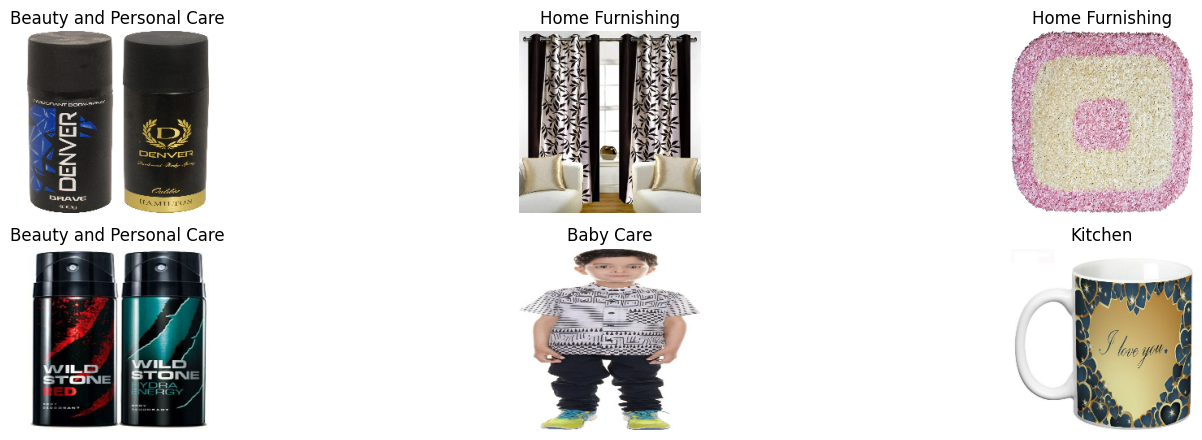

In [127]:
%%time
plt.figure(figsize=(18, 8))
for images, l in data_ds.take(4):
  for i in range(6):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(l[i].numpy().decode('utf-8'))
    plt.axis("off")

# 3. Extraction de caractéristiques via CNN (Transfer Learning)

In [128]:
def extract_features(dataset, model):
    features_list = []
    labels_list = []

    for images, labels in dataset:
        features = model.predict(images)
        features_list.append(features)
        labels_list.append(labels.numpy())

    # Concaténer tous les batches
    features_array = np.concatenate(features_list, axis=0)
    labels_array = np.concatenate(labels_list, axis=0)

    return features_array, labels_array

In [129]:
results = default_dict(dict)

## 3.1. Extraction des features avec ResNet50

In [130]:
resnet50_data_ds = data_ds.map(lambda x,y: (resnet_preprocess_input(x), y))

In [131]:
base_model = ResNet50(weights='imagenet', include_top=False, pooling='avg', input_shape=(224, 224, 3))
base_model.trainable = False
base_model.summary()

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_6[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 23,587,712 (89.98 MB)

In [132]:
%%time
resnet50_features = base_model.predict(resnet50_data_ds)

33/33 ━━━━━━━━━━━━━━━━━━━━ 59s 2s/step
CPU times: user 5min 13s, sys: 24 s, total: 5min 37s
Wall time: 59 s


In [133]:
print("Data features shape:", resnet50_features.shape)

Data features shape: (1050, 2048)


### 3.1.1. Réduction de dimensions

#### | PCA

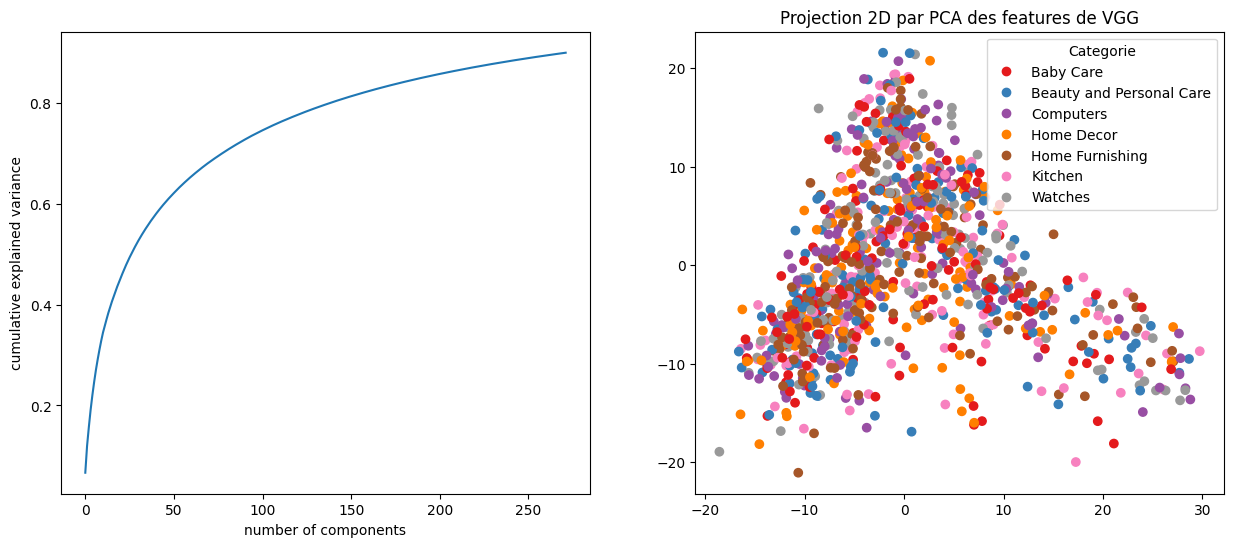

CPU times: user 6.98 s, sys: 31.9 ms, total: 7.01 s
Wall time: 1.18 s


In [134]:
%%time
scaler = StandardScaler()
pca = PCA(n_components=0.9)

scaled_resnet50_features = scaler.fit_transform(resnet50_features)
resnet50_X_pca = pca.fit_transform(resnet50_features)

fig = plt.figure(figsize=(15,6))

ax = fig.add_subplot(121)
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('number of components')
plt.ylabel('cumulative explained variance')

ax = fig.add_subplot(122)
scatter = plt.scatter(resnet50_X_pca[:,0],resnet50_X_pca[:,1], c=data.encoded_category.tolist(), cmap='Set1')
plt.legend(handles=scatter.legend_elements()[0], labels=np.unique(data.category).tolist(), loc="best", title="Categorie")
plt.title("Projection 2D par PCA des features de VGG")

plt.show()

In [135]:
resnet50_X_pca

array([[-3.3270252e-01,  1.7747459e+01, -2.8675406e+00, ...,
         2.8330725e-01, -9.3135767e-02,  6.7160480e-02],
       [-2.0310490e+00,  1.2673792e+01,  8.3808155e+00, ...,
         1.0847278e+00, -3.8926327e-01, -2.2078499e-01],
       [-5.1247053e+00, -6.8660736e+00,  1.2174847e+00, ...,
         3.1976104e-03, -2.4727042e-01, -5.5677027e-02],
       ...,
       [-8.4157419e+00, -7.0002327e+00,  6.3869530e-01, ...,
        -2.1937874e-01,  2.2937118e-01,  1.6407790e-02],
       [-4.0414211e-01, -8.3378773e+00, -2.5939906e+00, ...,
        -2.5398092e+00, -6.4899951e-01,  8.8138634e-01],
       [ 8.6686020e+00, -2.2391565e+00, -7.3736472e+00, ...,
        -7.6894426e-01,  5.8354819e-01,  2.5658837e-01]], dtype=float32)

#### | TSNE

In [136]:
for p in range(10,100,10):
    tsne = TSNE(n_components=2, perplexity=p, random_state=42)
    X = tsne.fit_transform(resnet50_X_pca)
    cls = KMeans(n_clusters=k, n_init=100, random_state=42)
    clusters = cls.fit_predict(X)
    ARI = np.round(adjusted_rand_score(data.encoded_category, clusters),4)
    print(f"ARI : {ARI} p={p}")

ARI : -0.0009 p=10
ARI : -0.0001 p=20
ARI : -0.0008 p=30
ARI : 0.0002 p=40
ARI : -0.0003 p=50
ARI : 0.0005 p=60
ARI : 0.0009 p=70
ARI : -0.0006 p=80
ARI : -0.0002 p=90


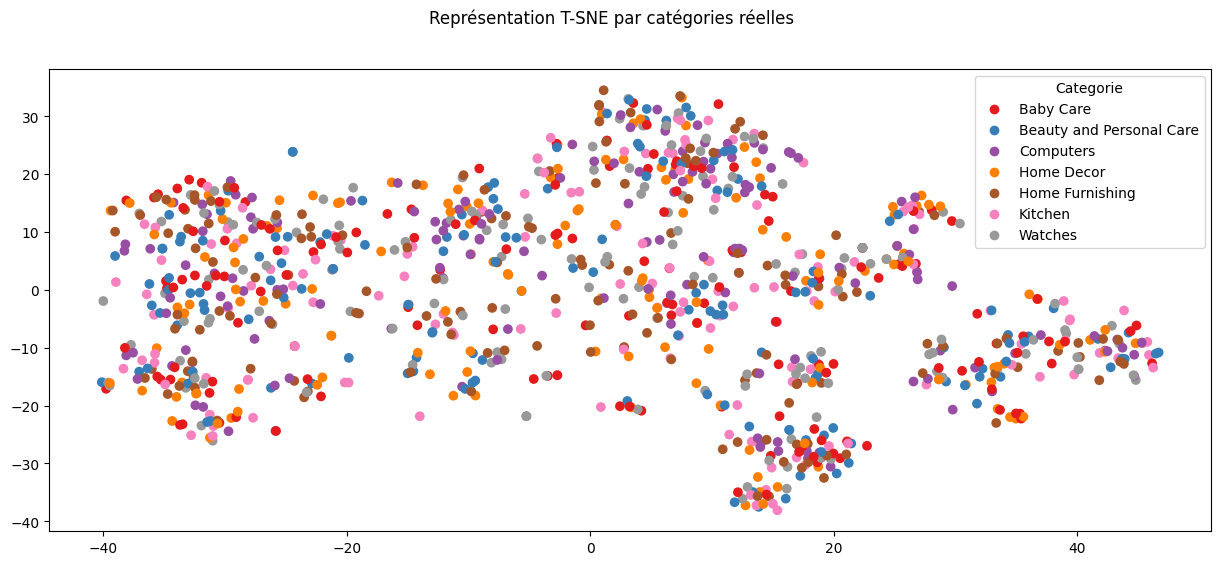

CPU times: user 14.4 s, sys: 30.3 ms, total: 14.4 s
Wall time: 3.57 s


In [137]:
%%time
fig = plt.figure(figsize=(15,6))
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
resnet50_X_tsne = tsne.fit_transform(resnet50_X_pca)
scatter = plt.scatter(resnet50_X_tsne[:,0],resnet50_X_tsne[:,1], c=data.encoded_category, cmap='Set1')
plt.legend(handles=scatter.legend_elements()[0], labels=np.unique(data.category).tolist(), loc="best", title="Categorie")

plt.suptitle("Représentation T-SNE par catégories réelles")
plt.show()

### 3.1.2. Kmeans clustering

In [138]:
def tsne_visu_fct(X_tsne, y_cat_num, labels, ARI):
    fig = plt.figure(figsize=(15,6))
    ax = fig.add_subplot(121)

    scatter = ax.scatter(X_tsne[:,0],X_tsne[:,1], c=y_cat_num, cmap='Set1')
    ax.legend(handles=scatter.legend_elements()[0], labels=set(y_cat_num), loc="best", title="Categorie")
    plt.title(f"Représentation des produits par catégories réelles")

    ax = fig.add_subplot(122)
    scatter = ax.scatter(X_tsne[:,0],X_tsne[:,1], c=labels, cmap='Set1')
    ax.legend(handles=scatter.legend_elements()[0], labels=set(labels), loc="best", title="Clusters")
    plt.title(f"Représentation des produits par clusters => ARI={ARI}")
    plt.show()

ARI :  -0.0008


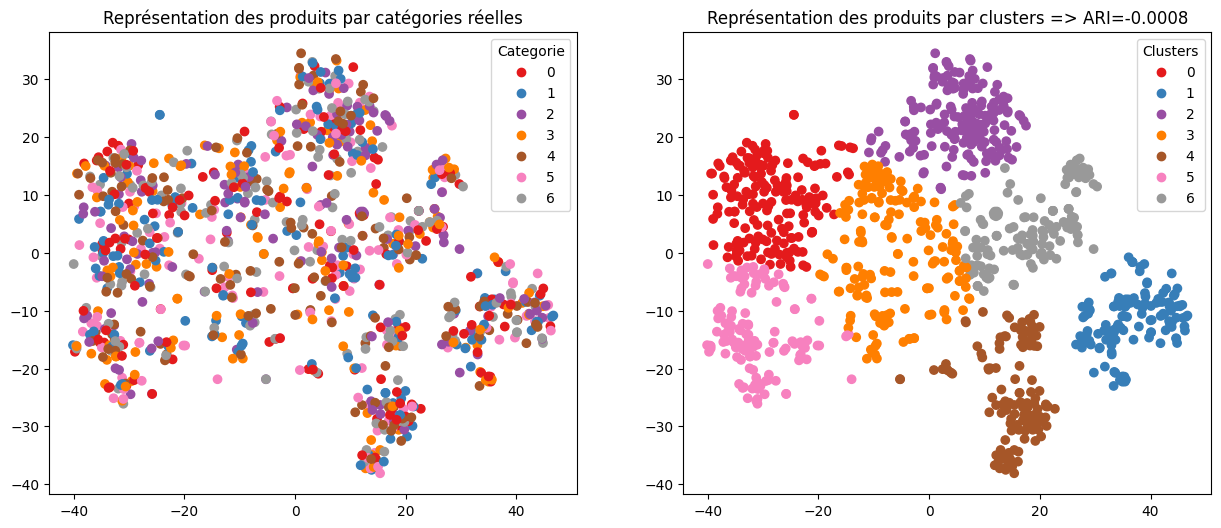

CPU times: user 2.82 s, sys: 66.2 ms, total: 2.89 s
Wall time: 871 ms


In [139]:
%%time

# Détermination des clusters à partir des données reduites
k=7

cls = KMeans(n_clusters=k, n_init=100, random_state=42)
clusters = cls.fit_predict(resnet50_X_tsne)
ARI = np.round(adjusted_rand_score(data.encoded_category, clusters),4)
results["Resnet50"] = {
    'Silhouette score': silhouette_score(resnet50_X_tsne, clusters, metric='euclidean'),
    'Davies-Bouldin score': davies_bouldin_score(resnet50_X_tsne, clusters),
}
print("ARI : ", ARI)
tsne_visu_fct(resnet50_X_tsne, data.encoded_category, clusters, ARI)

In [140]:
results

defaultdict(dict,
            {'Resnet50': {'Silhouette score': np.float32(0.46699068),
              'Davies-Bouldin score': np.float64(0.702374766203317)}})

In [141]:
clustered_df = pd.DataFrame(data.category, columns=['category'])
clustered_df['cluster'] = clusters

In [142]:
clustered_df

,category,cluster
0,Home Furnishing,2
1,Baby Care,6
2,Baby Care,5
3,Home Furnishing,5
4,Home Furnishing,4
...,...,...
1045,Baby Care,2
1046,Baby Care,0
1047,Baby Care,0
1048,Baby Care,5


In [143]:
clustered_df.groupby("cluster")["category"].value_counts().to_frame().reset_index()

,cluster,category,count
0,0,Baby Care,32
1,0,Beauty and Personal Care,28
2,0,Home Furnishing,26
3,0,Computers,25
4,0,Home Decor,25
5,0,Watches,21
6,0,Kitchen,20
7,1,Beauty and Personal Care,21
8,1,Baby Care,19
9,1,Kitchen,19


In [144]:
from sklearn import metrics
conf_mat = metrics.confusion_matrix(data.encoded_category, clustered_df.cluster)
print(conf_mat)

[[32 19 20 20 23 17 19]
 [28 21 24 22 22 18 15]
 [25 16 33 26 12 16 22]
 [25 17 24 28 14 20 22]
 [26 16 21 33 20 20 14]
 [20 19 24 19 21 19 28]
 [21 19 26 30 20 16 18]]


In [145]:
print(metrics.classification_report(data.encoded_category, clustered_df.cluster))

              precision    recall  f1-score   support

           0       0.18      0.21      0.20       150
           1       0.17      0.14      0.15       150
           2       0.19      0.22      0.20       150
           3       0.16      0.19      0.17       150
           4       0.15      0.13      0.14       150
           5       0.15      0.13      0.14       150
           6       0.13      0.12      0.12       150

    accuracy                           0.16      1050
   macro avg       0.16      0.16      0.16      1050
weighted avg       0.16      0.16      0.16      1050



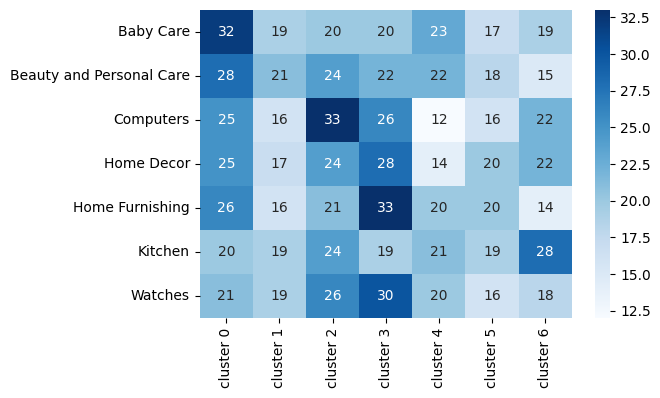

In [146]:
df_cm = pd.DataFrame(conf_mat, index = np.unique(data.category),
                  columns = [f"cluster {i}" for i in np.unique(data.encoded_category)])
plt.figure(figsize = (6,4))
sns.heatmap(df_cm, annot=True, cmap="Blues")
plt.show()

## 3.2 EXtraction des features avec VGG16

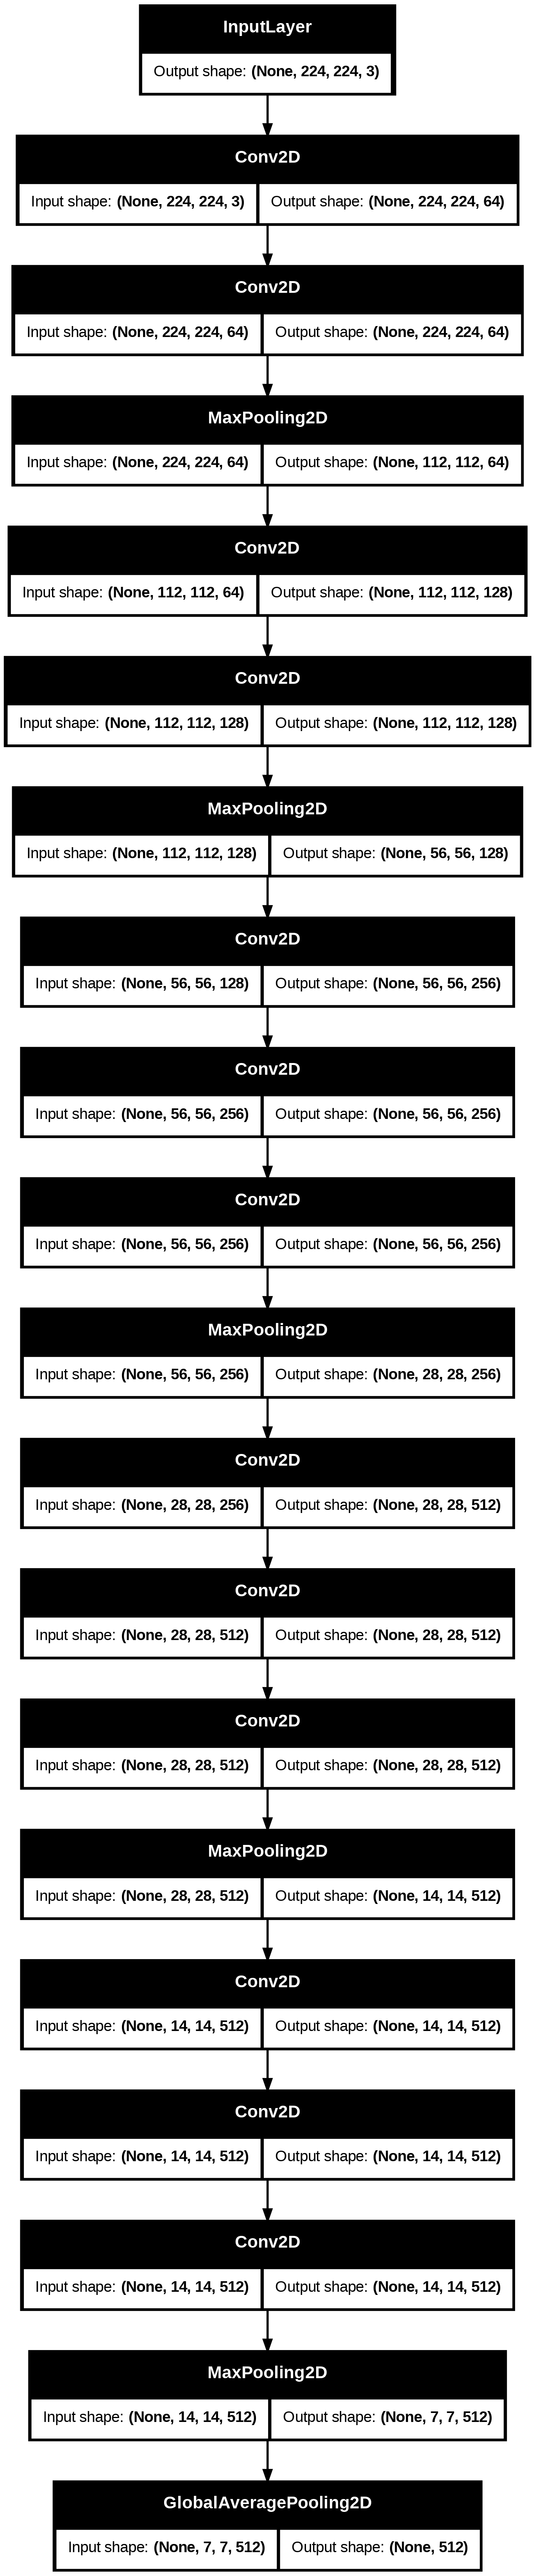

In [147]:
vgg_model = VGG16(weights='imagenet', include_top=False, pooling='avg', input_shape=(224, 224, 3))
tf.keras.utils.plot_model(vgg_model, show_shapes=True)

In [148]:
%%time
vgg_data_ds = data_ds.map(lambda x,y: (vgg_preprocess_input(x), y))
vgg_features = vgg_model.predict(vgg_data_ds)

Cause: could not parse the source code of <function <lambda> at 0x7b427dc33e20>: no matching AST found among candidates:

To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: could not parse the source code of <function <lambda> at 0x7b427dc33e20>: no matching AST found among candidates:

To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
33/33 ━━━━━━━━━━━━━━━━━━━━ 136s 4s/step
CPU times: user 15min 24s, sys: 40.3 s, total: 16min 4s
Wall time: 2min 16s


In [149]:
vgg_features.shape

(1050, 512)

### 3.2.1. Réduction de dimensions

#### | PCA

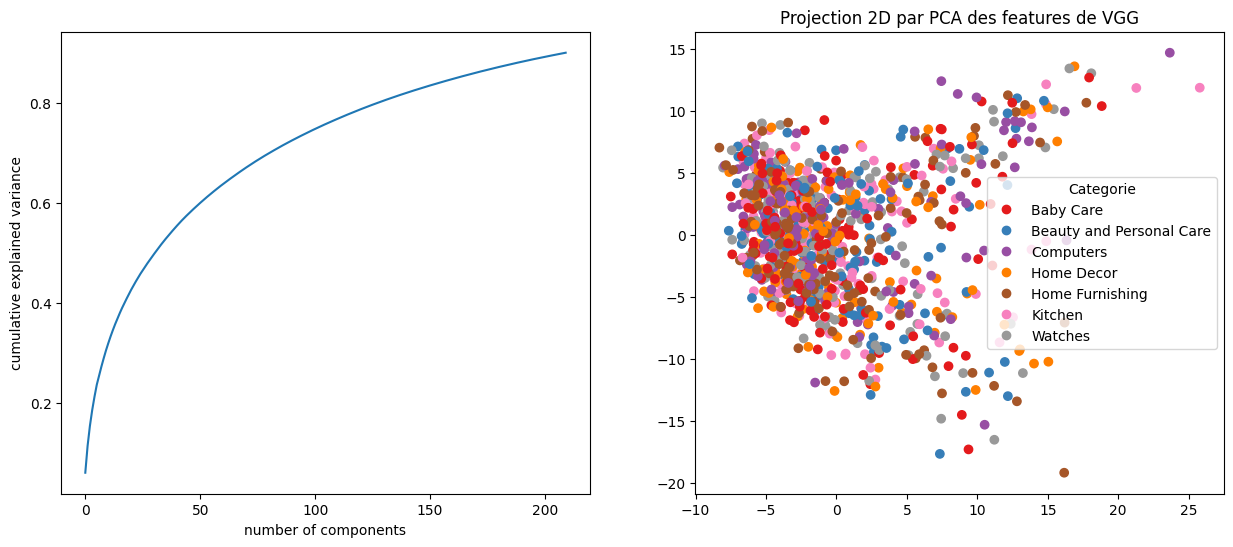

CPU times: user 2.12 s, sys: 18.7 ms, total: 2.14 s
Wall time: 510 ms


In [150]:
%%time
scaler = StandardScaler()
scaled_vgg_features = scaler.fit_transform(vgg_features)
pca = PCA(n_components=0.9)
vgg_x_pca = pca.fit_transform(scaled_vgg_features)

fig = plt.figure(figsize=(15,6))

ax = fig.add_subplot(121)
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('number of components')
plt.ylabel('cumulative explained variance')
ax = fig.add_subplot(122)

scatter = plt.scatter(vgg_x_pca[:,0],vgg_x_pca[:,1], c=data.encoded_category.tolist(), cmap='Set1')
plt.legend(handles=scatter.legend_elements()[0], labels=np.unique(data.category).tolist(), loc="best", title="Categorie")
plt.title("Projection 2D par PCA des features de VGG")
plt.show()

In [151]:
pca.components_.shape

(210, 512)

#### | T-SNE

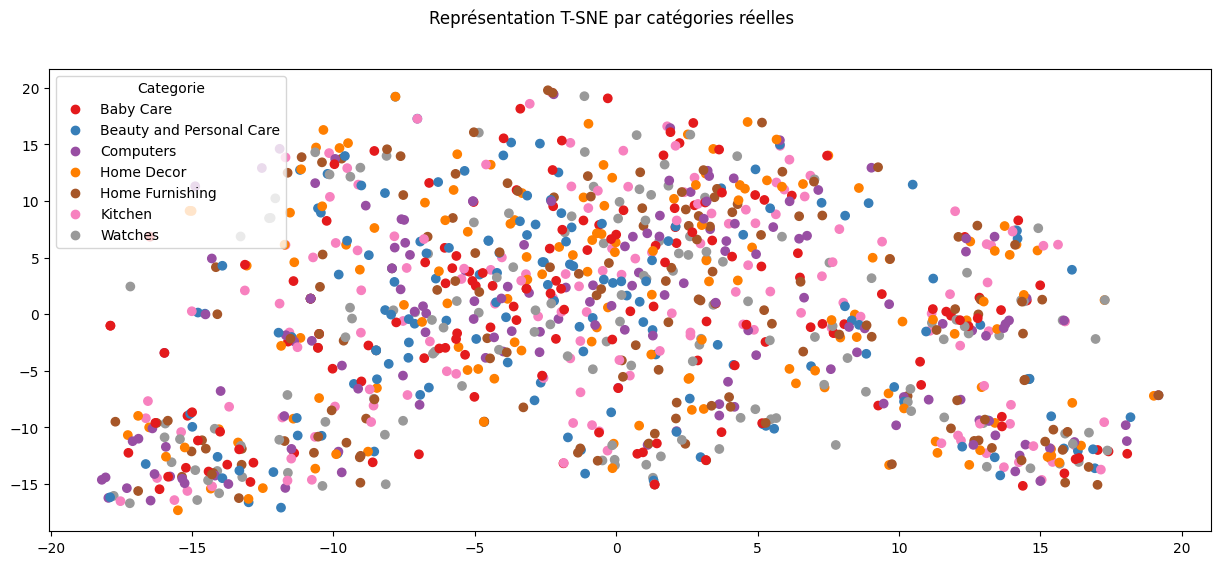

CPU times: user 21.5 s, sys: 66.9 ms, total: 21.5 s
Wall time: 5.52 s


In [152]:
%%time
fig = plt.figure(figsize=(15,6))
colors, _= pd.factorize(data.category)
tsne_data = []
tsne = TSNE(n_components=2, perplexity=70, random_state=42)
s = MinMaxScaler()
scaled_vgg_X_tsne = tsne.fit_transform(s.fit_transform(vgg_features))
vgg_X_tsne = s.fit_transform(vgg_features)
scatter = plt.scatter(scaled_vgg_X_tsne[:,0],scaled_vgg_X_tsne[:,1], c=data.encoded_category.tolist(), cmap='Set1')
plt.legend(handles=scatter.legend_elements()[0], labels=np.unique(data.category).tolist(), loc="best", title="Categorie")

plt.suptitle("Représentation T-SNE par catégories réelles")
plt.show()

### 3.2.2 Kmeans clustering

In [153]:
cls = KMeans(n_clusters=k, n_init=100, random_state=42)
clusters = cls.fit_predict(scaled_vgg_X_tsne)
ARI_1 = np.round(adjusted_rand_score(data.encoded_category, clusters),4)
clusters = cls.fit_predict(vgg_X_tsne)
ARI_2 = np.round(adjusted_rand_score(data.encoded_category, clusters),4)
print("ARI : ", ARI_1)
print("ARI : ", ARI_2)

ARI :  0.0021
ARI :  0.0012


ARI :  0.0008


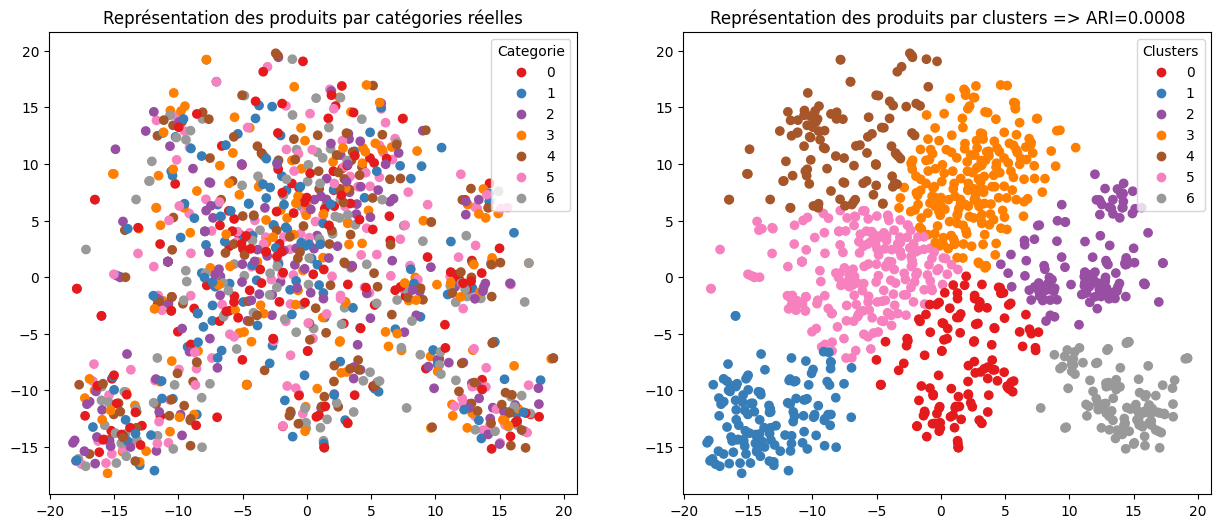

CPU times: user 1.53 s, sys: 11.4 ms, total: 1.54 s
Wall time: 532 ms


In [154]:
%%time

# Détermination des clusters à partir des données reduites
k=7
# Scaler

s_vgg_X_tsne = scaled_vgg_X_tsne
cls = KMeans(n_clusters=k, random_state=42)
clusters = cls.fit_predict(s_vgg_X_tsne)
ARI = np.round(adjusted_rand_score(data.encoded_category, clusters),4)
results["Vgg16"] = {
    'Silhouette score': silhouette_score(s_vgg_X_tsne, clusters, metric='euclidean'),
    'Davies-Bouldin score': davies_bouldin_score(s_vgg_X_tsne, clusters),
}
print("ARI : ", ARI)
tsne_visu_fct(s_vgg_X_tsne, data.encoded_category.tolist(), clusters, ARI)

## 3.3. Comparaison

### 3.3.1 Approche visuelle

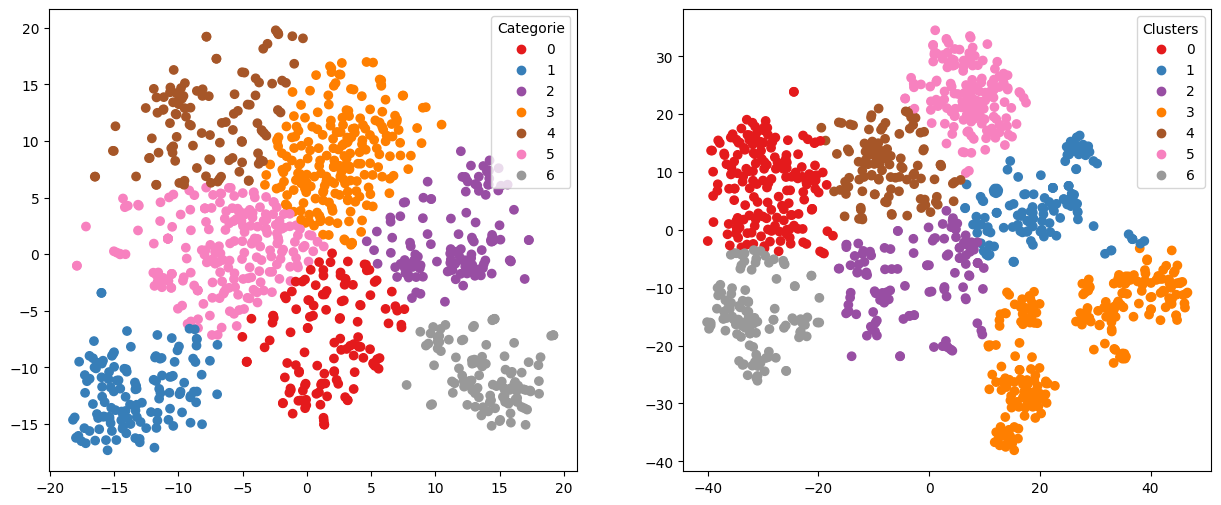

In [168]:
fig = plt.figure(figsize=(15,6))
ax = fig.add_subplot(121)
clusters1 = cls.fit_predict(s_vgg_X_tsne)
clusters2 = cls.fit_predict(resnet50_X_tsne)


scatter = ax.scatter(scaled_vgg_X_tsne[:,0],scaled_vgg_X_tsne[:,1], c=clusters1, cmap='Set1')
ax.legend(handles=scatter.legend_elements()[0], labels=set(clusters1), loc="best", title="Categorie")
#plt.title(f"Représentation des produits par catégories réelles")

ax = fig.add_subplot(122)
scatter = ax.scatter(resnet50_X_tsne[:,0],resnet50_X_tsne[:,1], c=clusters2, cmap='Set1')
ax.legend(handles=scatter.legend_elements()[0], labels=set(clusters2), loc="best", title="Clusters")
#plt.title(f"Représentation des produits par clusters => ARI={ARI}")
plt.show()

### 3.3.2 Approche quantitative

- Une valeur elevée Silhouette score indique des clusters plus compacts et mieux séparés (donc un meilleur clustering).

- Une valeur faible de Davies-Bouldin score indique des clusters plus compacts et mieux séparés (donc un meilleur clustering).

In [155]:
result_df = pd.DataFrame(results).T
result_df

,Silhouette score,Davies-Bouldin score
Resnet50,0.466991,0.702375
Vgg16,0.433762,0.753288


🧠 Conclusion : Les features extraites par ResNet50 semblent offrir une meilleure séparation des classes que celles de VGG16 pour ce dataset. Elles sont donc plus adaptées pour un apprentissage non supervisé ou un clustering efficace dans ce cas précis.

# 4. Classification supervisée

Nous allons utilisées les features extraites à partir de notre modéle precedent de resnet50

In [156]:
train_ds = df_to_dataset(train_df, batch_size=32, shuffle=True)
validation_ds = df_to_dataset(val_df, batch_size=32, shuffle=False)
test_ds = df_to_dataset(test_df, batch_size=32, shuffle=False)

## 4.1 Augmentation du jeu d'entrainement

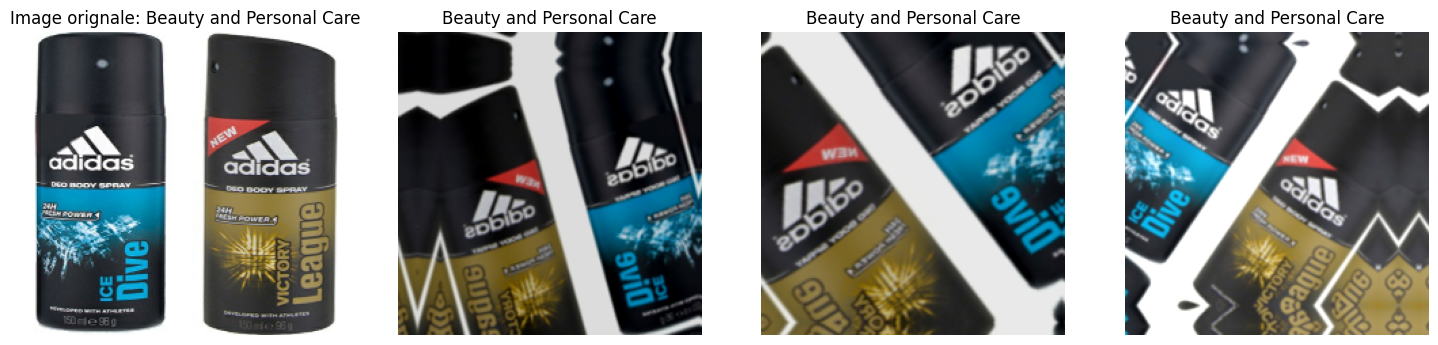

In [157]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),                       # Flip horizontal
    tf.keras.layers.RandomRotation(0.2),                            # Rotation aléatoire
    tf.keras.layers.RandomZoom(height_factor=0.2, width_factor=0.2),  # Zoom aléatoire
    tf.keras.layers.RandomTranslation(height_factor=0.1, width_factor=0.1),  # Translation aléatoire
    tf.keras.layers.RandomContrast(0.2),                            # Contraste aléatoire
    tf.keras.layers.RandomBrightness(factor=0.2),                   # Luminosité aléatoire (TF >= 2.15)
])

for image, labels in train_ds.take(1):
  plt.figure(figsize=(18, 8))
  first_image = image[0]
  label = labels[0].numpy().decode('utf-8')
  ax = plt.subplot(1, 4, 1)
  plt.imshow(first_image / 255)
  plt.title(f"Image orignale: {label}")
  plt.axis('off')
  for i in range(3):
    ax = plt.subplot(1, 4, i + 2)
    augmented_image = data_augmentation(tf.expand_dims(first_image, 0))
    plt.imshow(augmented_image[0] / 255)
    plt.title(label)
    plt.axis('off')

In [158]:
# Data augmentation appliquée à chaque image du dataset
#train_ds = train_ds.map(
#    lambda x, y: (data_augmentation(x, training=True), y),
#    num_parallel_calls=tf.data.AUTOTUNE
#)

## 4.2. Modélisation

In [159]:
# Chargement du modèle ResNet50 sans la tête (top) et avec poids ImageNet
base_model = ResNet50(weights='imagenet', include_top=False, pooling='avg')
# Gel des couches convolutives pour ne pas les réentraîner au début
base_model.trainable = False

In [160]:
tf.keras.utils.plot_model(base_model, show_shapes=True)

In [161]:
%%time
train_features, train_labels = extract_features(train_ds, base_model)
val_features, val_labels = extract_features(validation_ds, base_model)
test_features, test_labels = extract_features(test_ds, base_model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 

In [162]:
print("Train features shape:", train_features.shape)
print("Validation features shape:", val_features.shape)
print("Test features shape:", test_features.shape)

Train features shape: (735, 2048)
Validation features shape: (252, 2048)
Test features shape: (63, 2048)


In [163]:
%%time
# Nouvelle tête
inputs = Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = resnet_preprocess_input(x)
x = base_model(inputs, training=False)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(7, activation='softmax')(x)

model = Model(inputs, outputs)

In [164]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Fit on all labels to get unique mappings
label_encoder.fit(np.concatenate((train_labels, val_labels)))

# Transform labels to numerical values
train_labels_encoded = label_encoder.transform(train_labels)
val_labels_encoded = label_encoder.transform(val_labels)

input_ds = df_to_dataset(data, batch_size=32, shuffle=False, encoded_category=True)
input_validation_ds = df_to_dataset(data, batch_size=32, shuffle=False, encoded_category=True)
history = model.fit(
    input_ds,
    validation_data=input_validation_ds,
    epochs=10
)

Epoch 1/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 110s 3s/step - accuracy: 0.2461 - loss: 3.1553 - val_accuracy: 0.6390 - val_loss: 1.1560
Epoch 2/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 99s 3s/step - accuracy: 0.5449 - loss: 1.2276 - val_accuracy: 0.7162 - val_loss: 0.8724
Epoch 3/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 99s 3s/step - accuracy: 0.7143 - loss: 0.8814 - val_accuracy: 0.7829 - val_loss: 0.6771
Epoch 4/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 143s 3s/step - accuracy: 0.7394 - loss: 0.7798 - val_accuracy: 0.8124 - val_loss: 0.5635
Epoch 5/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 133s 4s/step - accuracy: 0.7758 - loss: 0.6368 - val_accuracy: 0.8800 - val_loss: 0.4050
Epoch 6/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 134s 4s/step - accuracy: 0.8485 - loss: 0.4498 - val_accuracy: 0.8848 - val_loss: 0.3410
Epoch 7/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 125s 4s/step - accuracy: 0.8769 - loss: 0.4008 - val_accuracy: 0.9219 - val_loss: 0.2602
Epoch 8/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 84s 3s/step - accuracy: 0.8884 - loss: 0.3386 - val_accuracy: 0.9438 - val_

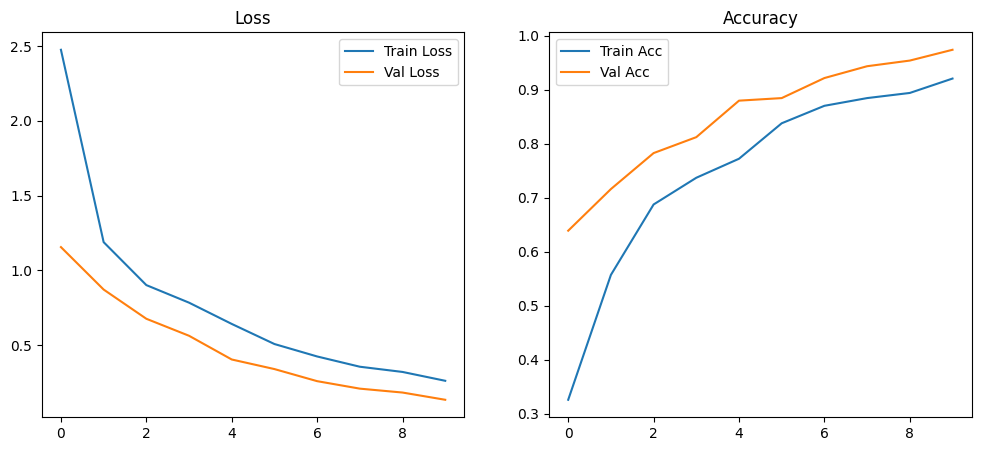

In [165]:
# Courbes Loss/Accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.legend()
plt.show()

In [ ]:
# Unfreeze the base model
base_model.trainable = True

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train end-to-end. Be careful to stop before you overfit!
h = model.fit(input_ds, epochs=10, validation_data=input_validation_ds)
# Courbes Loss/Accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(h.history['loss'], label='Train Loss')
plt.plot(h.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(h.history['accuracy'], label='Train Acc')
plt.plot(h.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.legend()
plt.show()

Epoch 1/10
24/33 ━━━━━━━━━━━━━━━━━━━━ 58s 6s/step - accuracy: 0.1831 - loss: 1.9715 

In [169]:
print("Test dataset evaluation")
model.evaluate(test_ds)

Test dataset evaluation


UnimplementedError: Graph execution error:

Detected at node compile_loss/sparse_categorical_crossentropy/Cast defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/usr/local/lib/python3.11/dist-packages/colab_kernel_launcher.py", line 37, in <module>

  File "/usr/local/lib/python3.11/dist-packages/traitlets/config/application.py", line 992, in launch_instance

  File "/usr/local/lib/python3.11/dist-packages/ipykernel/kernelapp.py", line 712, in start

  File "/usr/local/lib/python3.11/dist-packages/tornado/platform/asyncio.py", line 205, in start

  File "/usr/lib/python3.11/asyncio/base_events.py", line 608, in run_forever

  File "/usr/lib/python3.11/asyncio/base_events.py", line 1936, in _run_once

  File "/usr/lib/python3.11/asyncio/events.py", line 84, in _run

  File "/usr/local/lib/python3.11/dist-packages/ipykernel/kernelbase.py", line 510, in dispatch_queue

  File "/usr/local/lib/python3.11/dist-packages/ipykernel/kernelbase.py", line 499, in process_one

  File "/usr/local/lib/python3.11/dist-packages/ipykernel/kernelbase.py", line 406, in dispatch_shell

  File "/usr/local/lib/python3.11/dist-packages/ipykernel/kernelbase.py", line 730, in execute_request

  File "/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py", line 383, in do_execute

  File "/usr/local/lib/python3.11/dist-packages/ipykernel/zmqshell.py", line 528, in run_cell

  File "/usr/local/lib/python3.11/dist-packages/IPython/core/interactiveshell.py", line 2975, in run_cell

  File "/usr/local/lib/python3.11/dist-packages/IPython/core/interactiveshell.py", line 3030, in _run_cell

  File "/usr/local/lib/python3.11/dist-packages/IPython/core/async_helpers.py", line 78, in _pseudo_sync_runner

  File "/usr/local/lib/python3.11/dist-packages/IPython/core/interactiveshell.py", line 3257, in run_cell_async

  File "/usr/local/lib/python3.11/dist-packages/IPython/core/interactiveshell.py", line 3473, in run_ast_nodes

  File "/usr/local/lib/python3.11/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code

  File "<ipython-input-169-59dabf656729>", line 2, in <cell line: 0>

  File "/usr/local/lib/python3.11/dist-packages/keras/src/utils/traceback_utils.py", line 117, in error_handler

  File "/usr/local/lib/python3.11/dist-packages/keras/src/backend/tensorflow/trainer.py", line 484, in evaluate

  File "/usr/local/lib/python3.11/dist-packages/keras/src/backend/tensorflow/trainer.py", line 219, in function

  File "/usr/local/lib/python3.11/dist-packages/keras/src/backend/tensorflow/trainer.py", line 132, in multi_step_on_iterator

  File "/usr/local/lib/python3.11/dist-packages/keras/src/backend/tensorflow/trainer.py", line 113, in one_step_on_data

  File "/usr/local/lib/python3.11/dist-packages/keras/src/backend/tensorflow/trainer.py", line 92, in test_step

  File "/usr/local/lib/python3.11/dist-packages/keras/src/trainers/trainer.py", line 383, in _compute_loss

  File "/usr/local/lib/python3.11/dist-packages/keras/src/trainers/trainer.py", line 351, in compute_loss

  File "/usr/local/lib/python3.11/dist-packages/keras/src/trainers/compile_utils.py", line 691, in __call__

  File "/usr/local/lib/python3.11/dist-packages/keras/src/trainers/compile_utils.py", line 700, in call

  File "/usr/local/lib/python3.11/dist-packages/keras/src/losses/loss.py", line 63, in __call__

  File "/usr/local/lib/python3.11/dist-packages/keras/src/tree/tree_api.py", line 192, in map_structure

  File "/usr/local/lib/python3.11/dist-packages/keras/src/tree/optree_impl.py", line 108, in map_structure

  File "/usr/local/lib/python3.11/dist-packages/optree/ops.py", line 766, in tree_map

  File "/usr/local/lib/python3.11/dist-packages/keras/src/losses/loss.py", line 64, in <lambda>

  File "/usr/local/lib/python3.11/dist-packages/keras/src/ops/core.py", line 952, in convert_to_tensor

  File "/usr/local/lib/python3.11/dist-packages/keras/src/backend/tensorflow/core.py", line 144, in convert_to_tensor

Cast string to float is not supported
	 [[{{node compile_loss/sparse_categorical_crossentropy/Cast}}]] [Op:__inference_multi_step_on_iterator_56159]